# Analytic Method: CS-01 TAS

**Purpose**: solve the Tele Assistance System as an open Jackson queueing network in closed form (M/M/c/K per node) across the full adaptation axis and check it against the Camara 2023 R1 / R2 / R3 targets.

**Inputs**: `data/config/profile/{dflt,opti}.json` (PACS-style Variable dicts) and `data/reference/baseline.json` (R1 / R2 / R3 thresholds).

**Outputs**:
- `data/results/analytic/<adaptation>/<profile>.json` - per-run metrics (nodes + network + routing + lambda_z).
- `data/results/analytic/<adaptation>/requirements.json` - R1 / R2 / R3 verdicts.
- `data/img/analytic/<adaptation>/*.png` - topology, heatmap, bars, delta figures.

**Equivalent CLI** (reproduces the four runs written by this notebook):
```bash
python -m src.methods.analytic --adaptation baseline
python -m src.methods.analytic --adaptation s1
python -m src.methods.analytic --adaptation s2
python -m src.methods.analytic --adaptation aggregate
```

This notebook is thin: all logic lives in `src.methods.analytic` and `src.view.qn_diagram`. The cells below just orchestrate, display, and save figures.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.methods.analytic import run
from src.view import (
    plot_qn_topology,
    # plot_qn_topology_grid,
    plot_nd_heatmap,
    plot_nd_diffmap,
    plot_net_bars,
    plot_net_delta,
)

_IMG_ROOT = Path("data/img/analytic")
_ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# Human-readable scenario labels for plot titles / legends.
# `aggregate` is the fully-adapted configuration (opti routing + opti
# services at the three swap slots) so it is labelled "After Adaptation".
_DISPLAY = {
    "baseline":  "Before Adaptation",
    "s1":        "S1: Service-Failure Adapt.",
    "s2":        "S2: Response-Time Adapt.",
    "aggregate": "After Adaptation",
}

## 1. Solve every adaptation

`run(adp=a, wrt=True)` loads the resolved `NetworkConfig`, solves the Jackson network, writes the per-run envelope under `data/results/analytic/<adaptation>/`, and returns the per-node + aggregate DataFrames plus the R1 / R2 / R3 verdict.

In [2]:
_results = {_a: run(adp=_a, wrt=True) for _a in _ADAPTATIONS}

# unpack the per-adaptation pieces used in every later cell
_cfgs = {_a: _results[_a]["config"] for _a in _ADAPTATIONS}
_nodes = {_a: _results[_a]["nodes"] for _a in _ADAPTATIONS}
_nets = {_a: _results[_a]["network"] for _a in _ADAPTATIONS}
_reqs = {_a: _results[_a]["requirements"] for _a in _ADAPTATIONS}

print(f"Solved {len(_results)} adaptations; wrote JSONs under data/results/analytic/")

Solved 4 adaptations; wrote JSONs under data/results/analytic/


## 2. Network-wide summary + verdict

One row per adaptation: headline metrics (response time, utilisation, queue length) and the R1 / R2 / R3 pass flags.

In [3]:
_rows = []
for _a in _ADAPTATIONS:
    _n = _nets[_a].iloc[0]
    _r = _reqs[_a]
    _rows.append({
        "adaptation": _a,
        "profile": _cfgs[_a].profile,
        "W_net (ms)": _n["W_net"] * 1000,
        "avg_rho": _n["avg_rho"],
        "max_rho": _n["max_rho"],
        "L_net": _n["L_net"],
        "R1": "PASS" if _r["R1"]["pass"] else "FAIL",
        "R2": "PASS" if _r["R2"]["pass"] else "FAIL",
        "R3": "PASS" if _r["R3"]["pass"] else "FAIL",
    })
_summary = pd.DataFrame(_rows).set_index("adaptation")
_summary.round(4)

,profile,W_net (ms),avg_rho,max_rho,L_net,R1,R2,R3
adaptation,,,,,,,,
baseline,dflt,3.4365,0.2973,0.6942,6.9873,PASS,PASS,PASS
s1,opti,3.4079,0.2906,0.7500,6.8682,PASS,PASS,PASS
s2,opti,3.5575,0.3050,0.7119,7.2289,PASS,PASS,PASS
aggregate,opti,3.1073,0.2840,0.6900,6.2808,PASS,PASS,PASS


## 3. Per-node snapshot (baseline)

The reference configuration before any adaptation kicks in. `rho = lambda / (c * mu)`; `W`, `Wq` are in seconds; `L`, `Lq` are mean request counts.

In [4]:
_nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,345.0000,900.0,1,10,0.3833,0.6213,0.0018
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,258.7500,700.0,1,10,0.3696,0.5862,0.0023
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,173.3453,700.0,1,10,0.2476,0.3291,0.0019
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,97.0312,180.0,1,10,0.5391,1.1572,0.0119
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,91.8145,530.0,1,10,0.1732,0.2095,0.0023
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,104.1311,150.0,1,10,0.6942,2.0680,0.0200
6,AS_{1},Alarm Service 1,M/M/s/K,64.2741,700.0,1,10,0.0918,0.1011,0.0016
7,AS_{2},Alarm Service 2,M/M/s/K,59.5874,410.0,1,10,0.1453,0.1700,0.0029
8,AS_{3},Alarm Service 3,M/M/s/K,69.7609,1580.0,1,10,0.0442,0.0462,0.0007
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,256.1625,700.0,1,10,0.3659,0.5770,0.0023


## 4. Queue-network topology (architecture view)

Nodes are coloured by `rho` (cool = low, warm = high). Edge labels show routing probabilities.

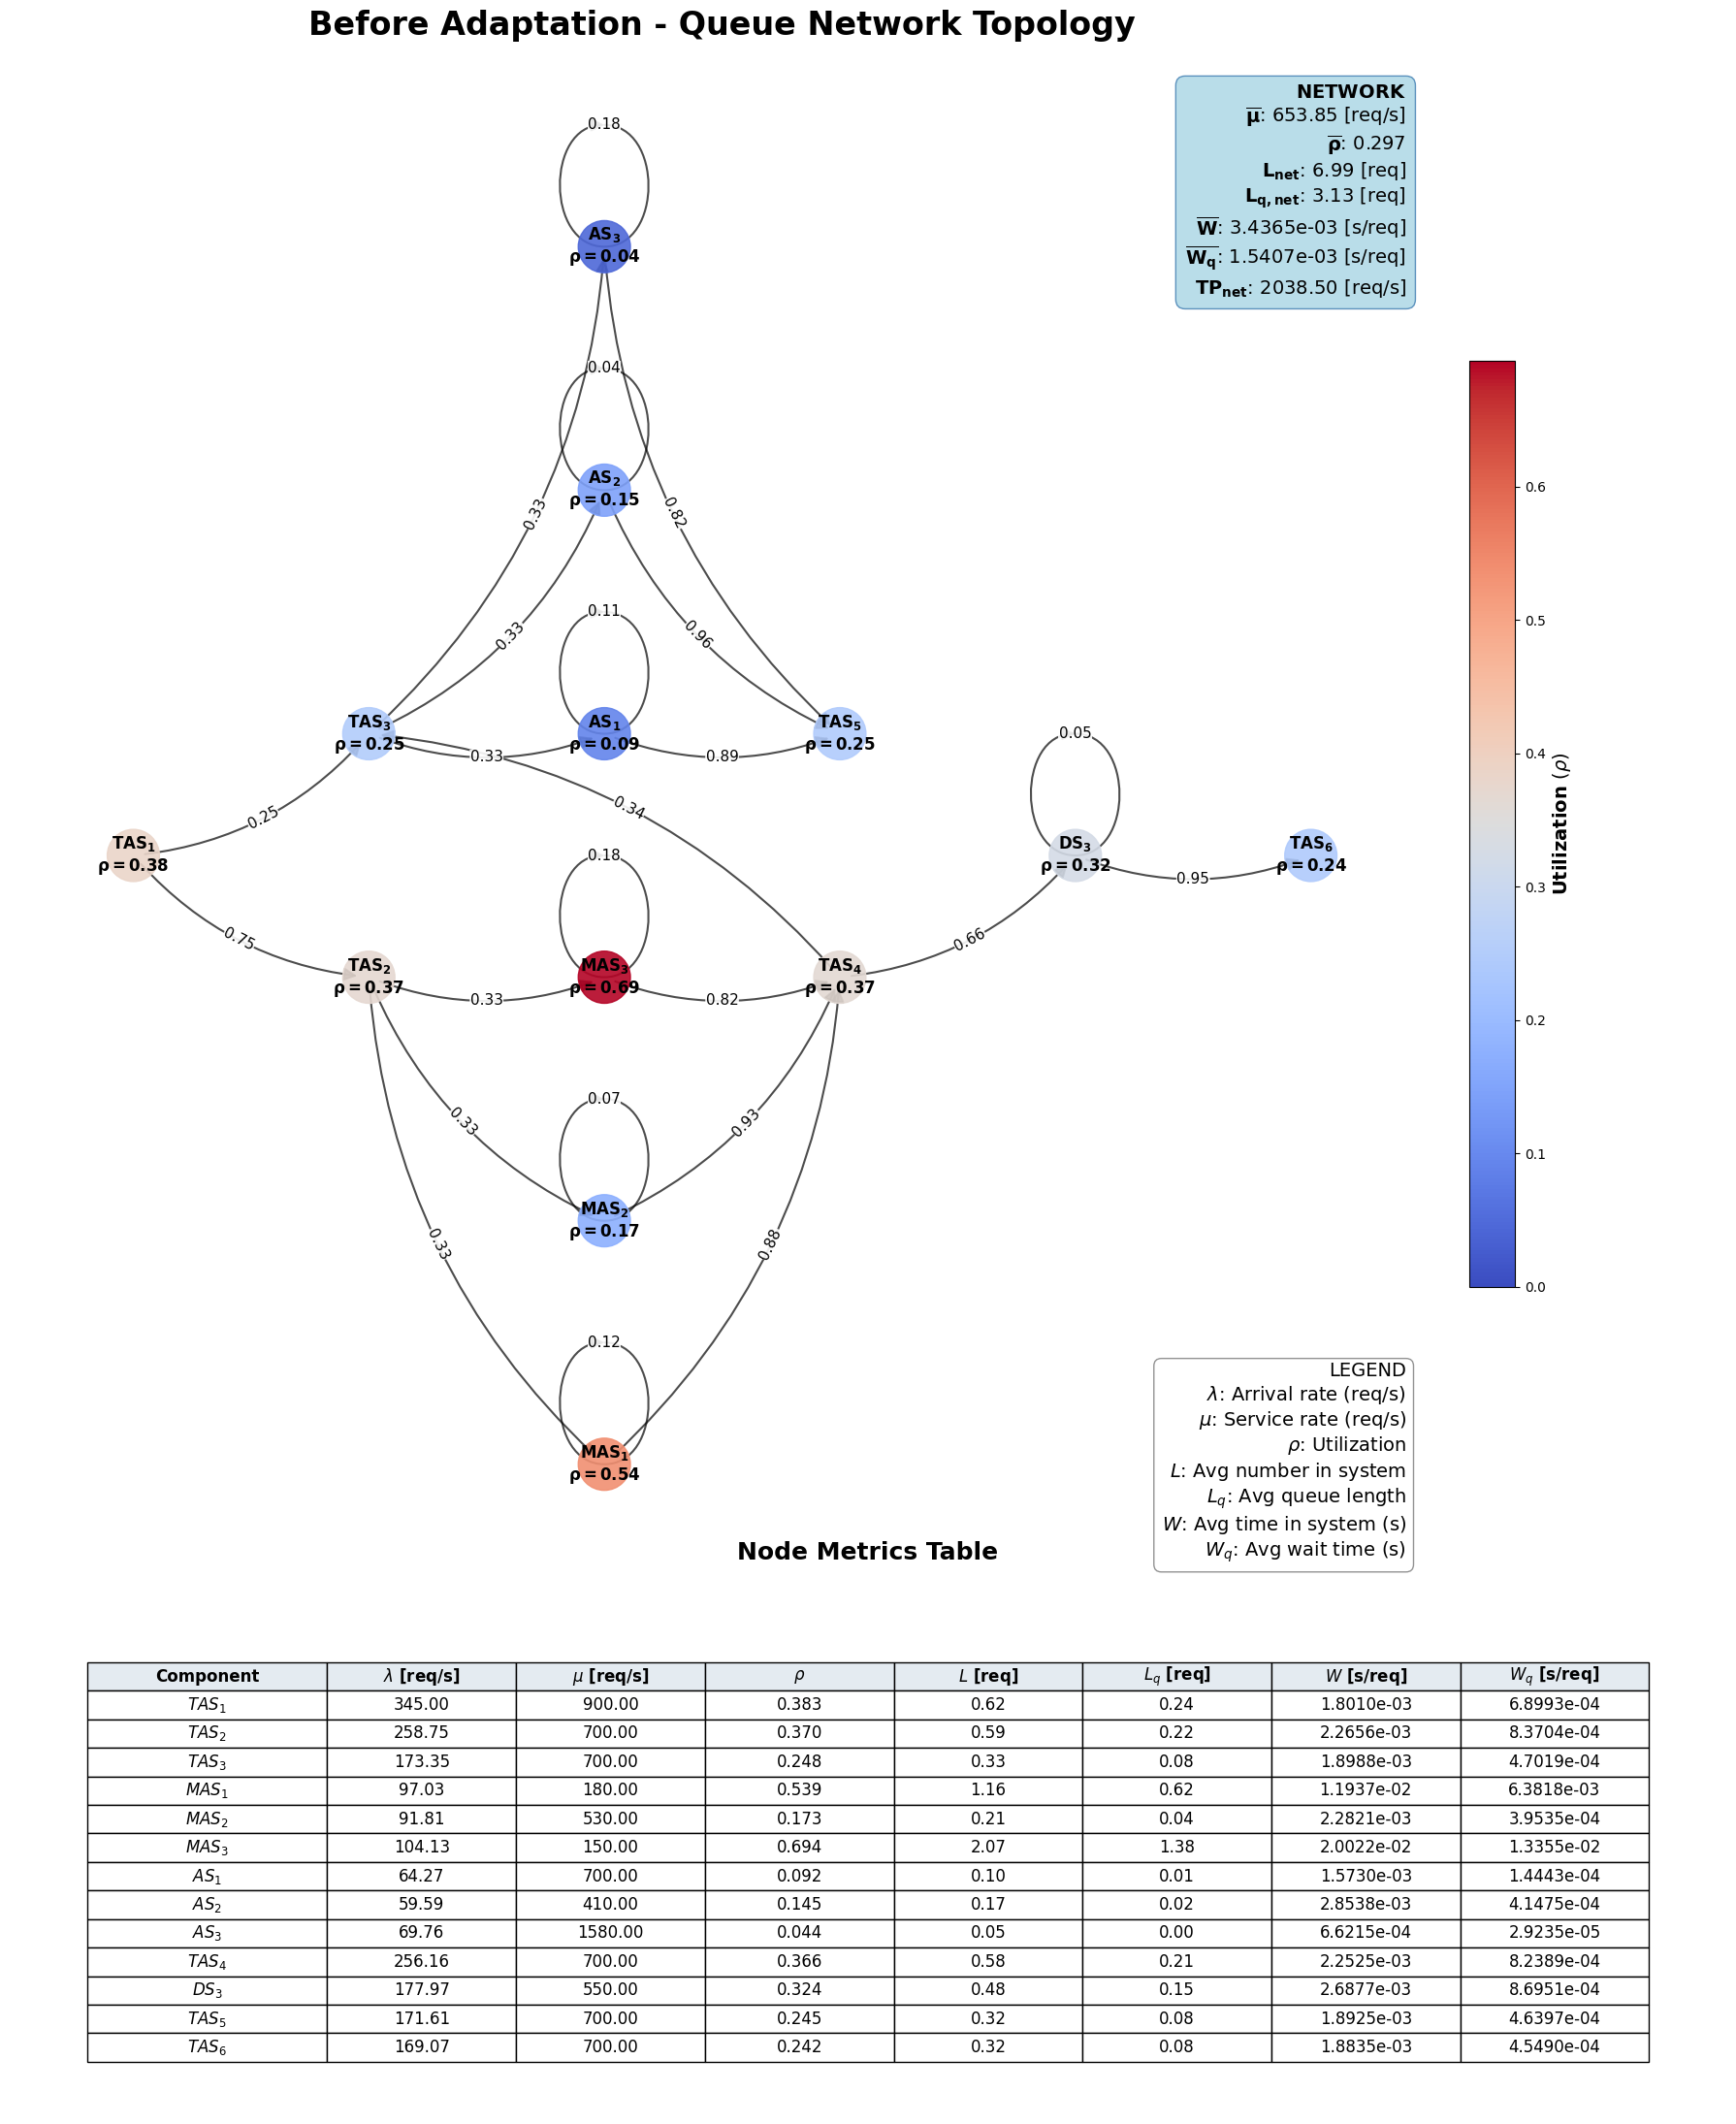

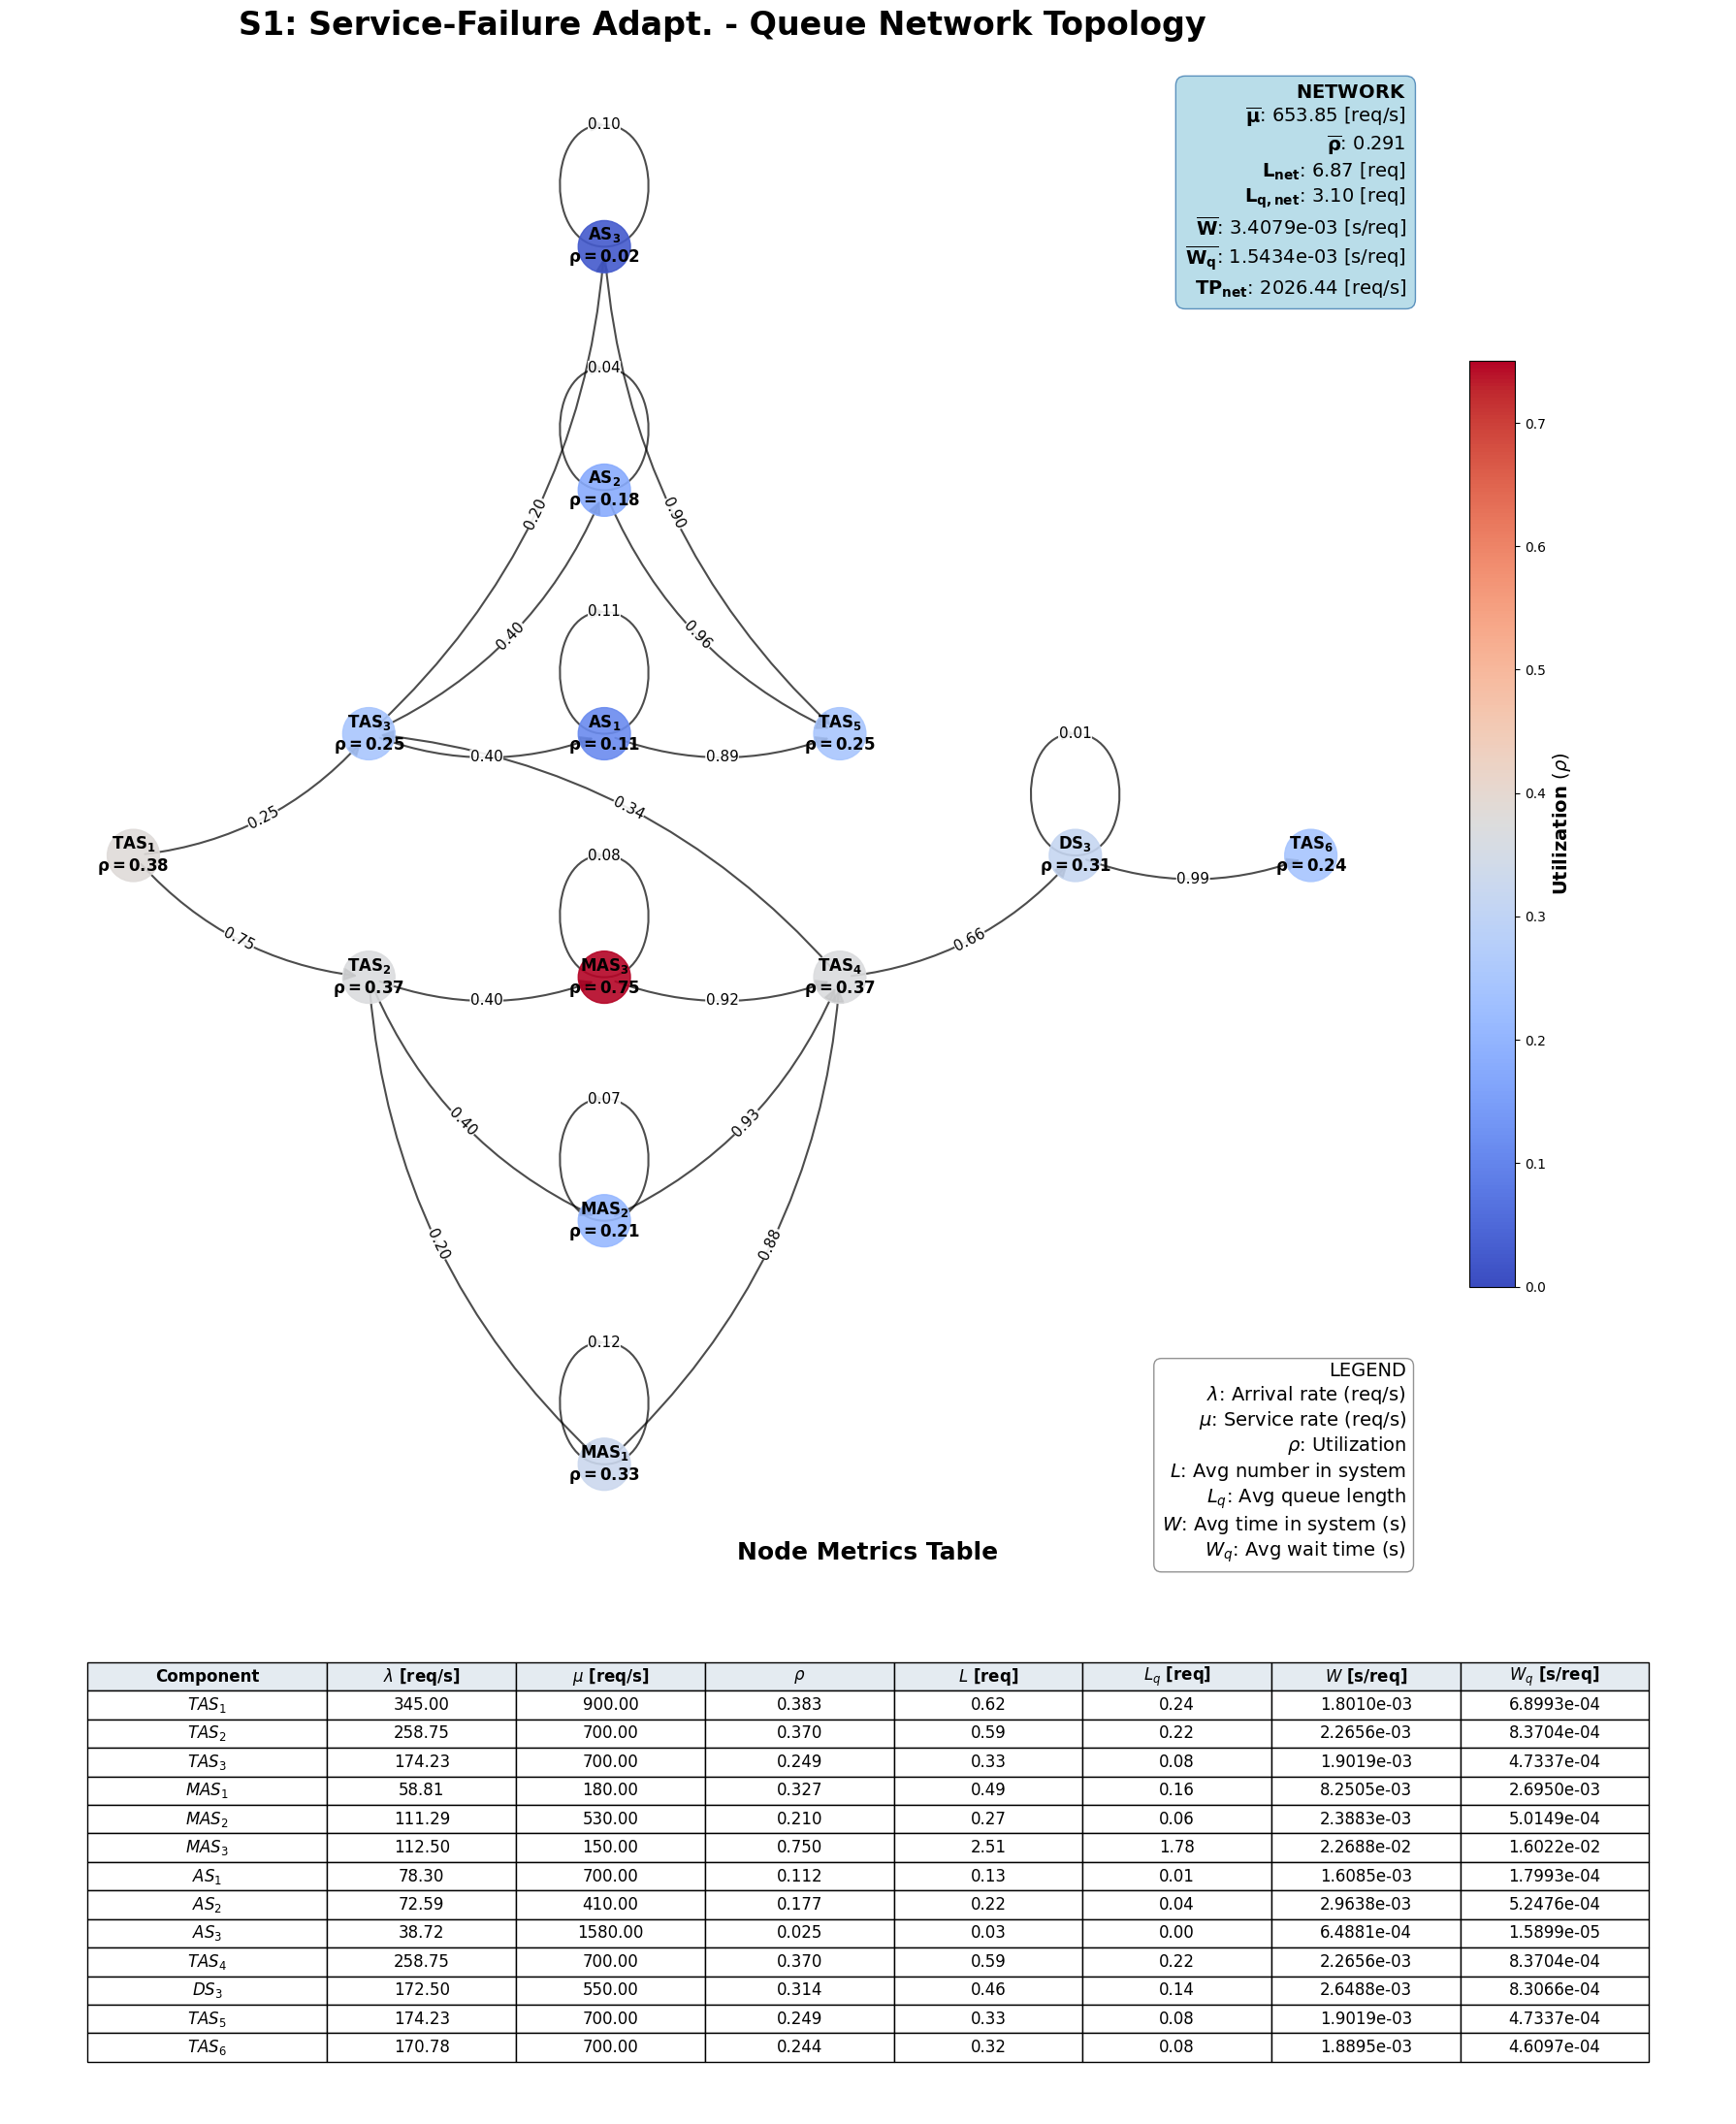

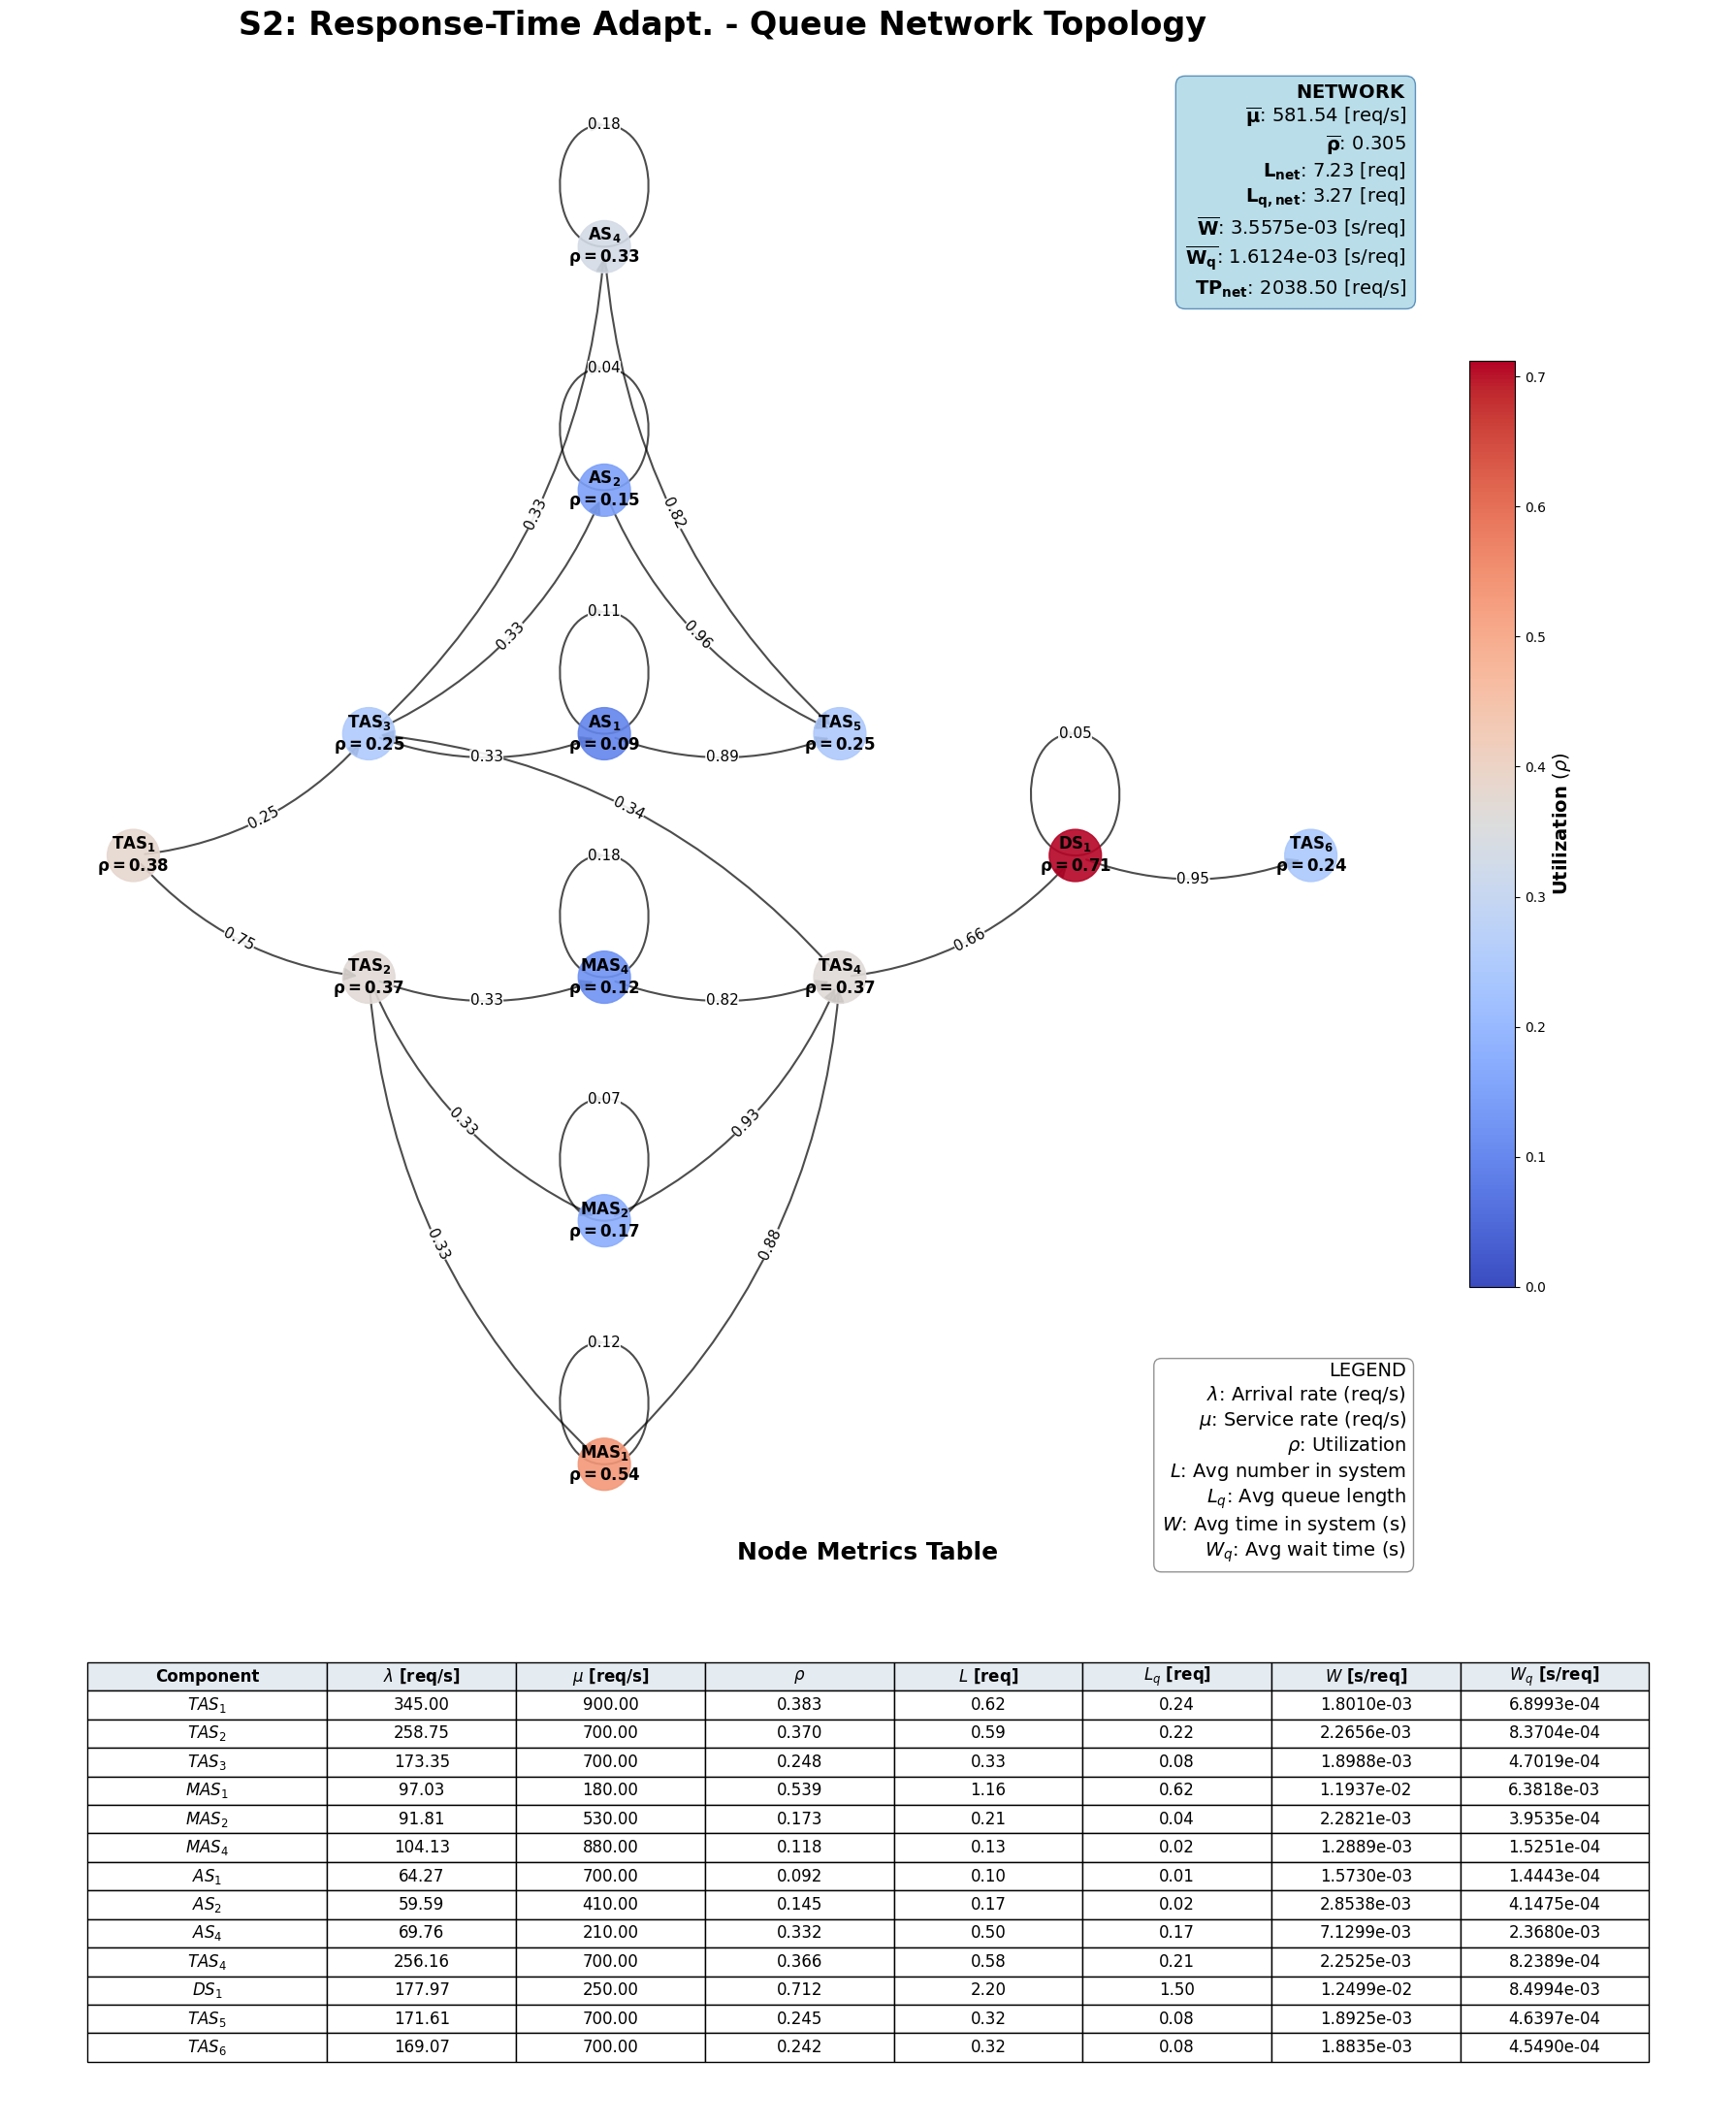

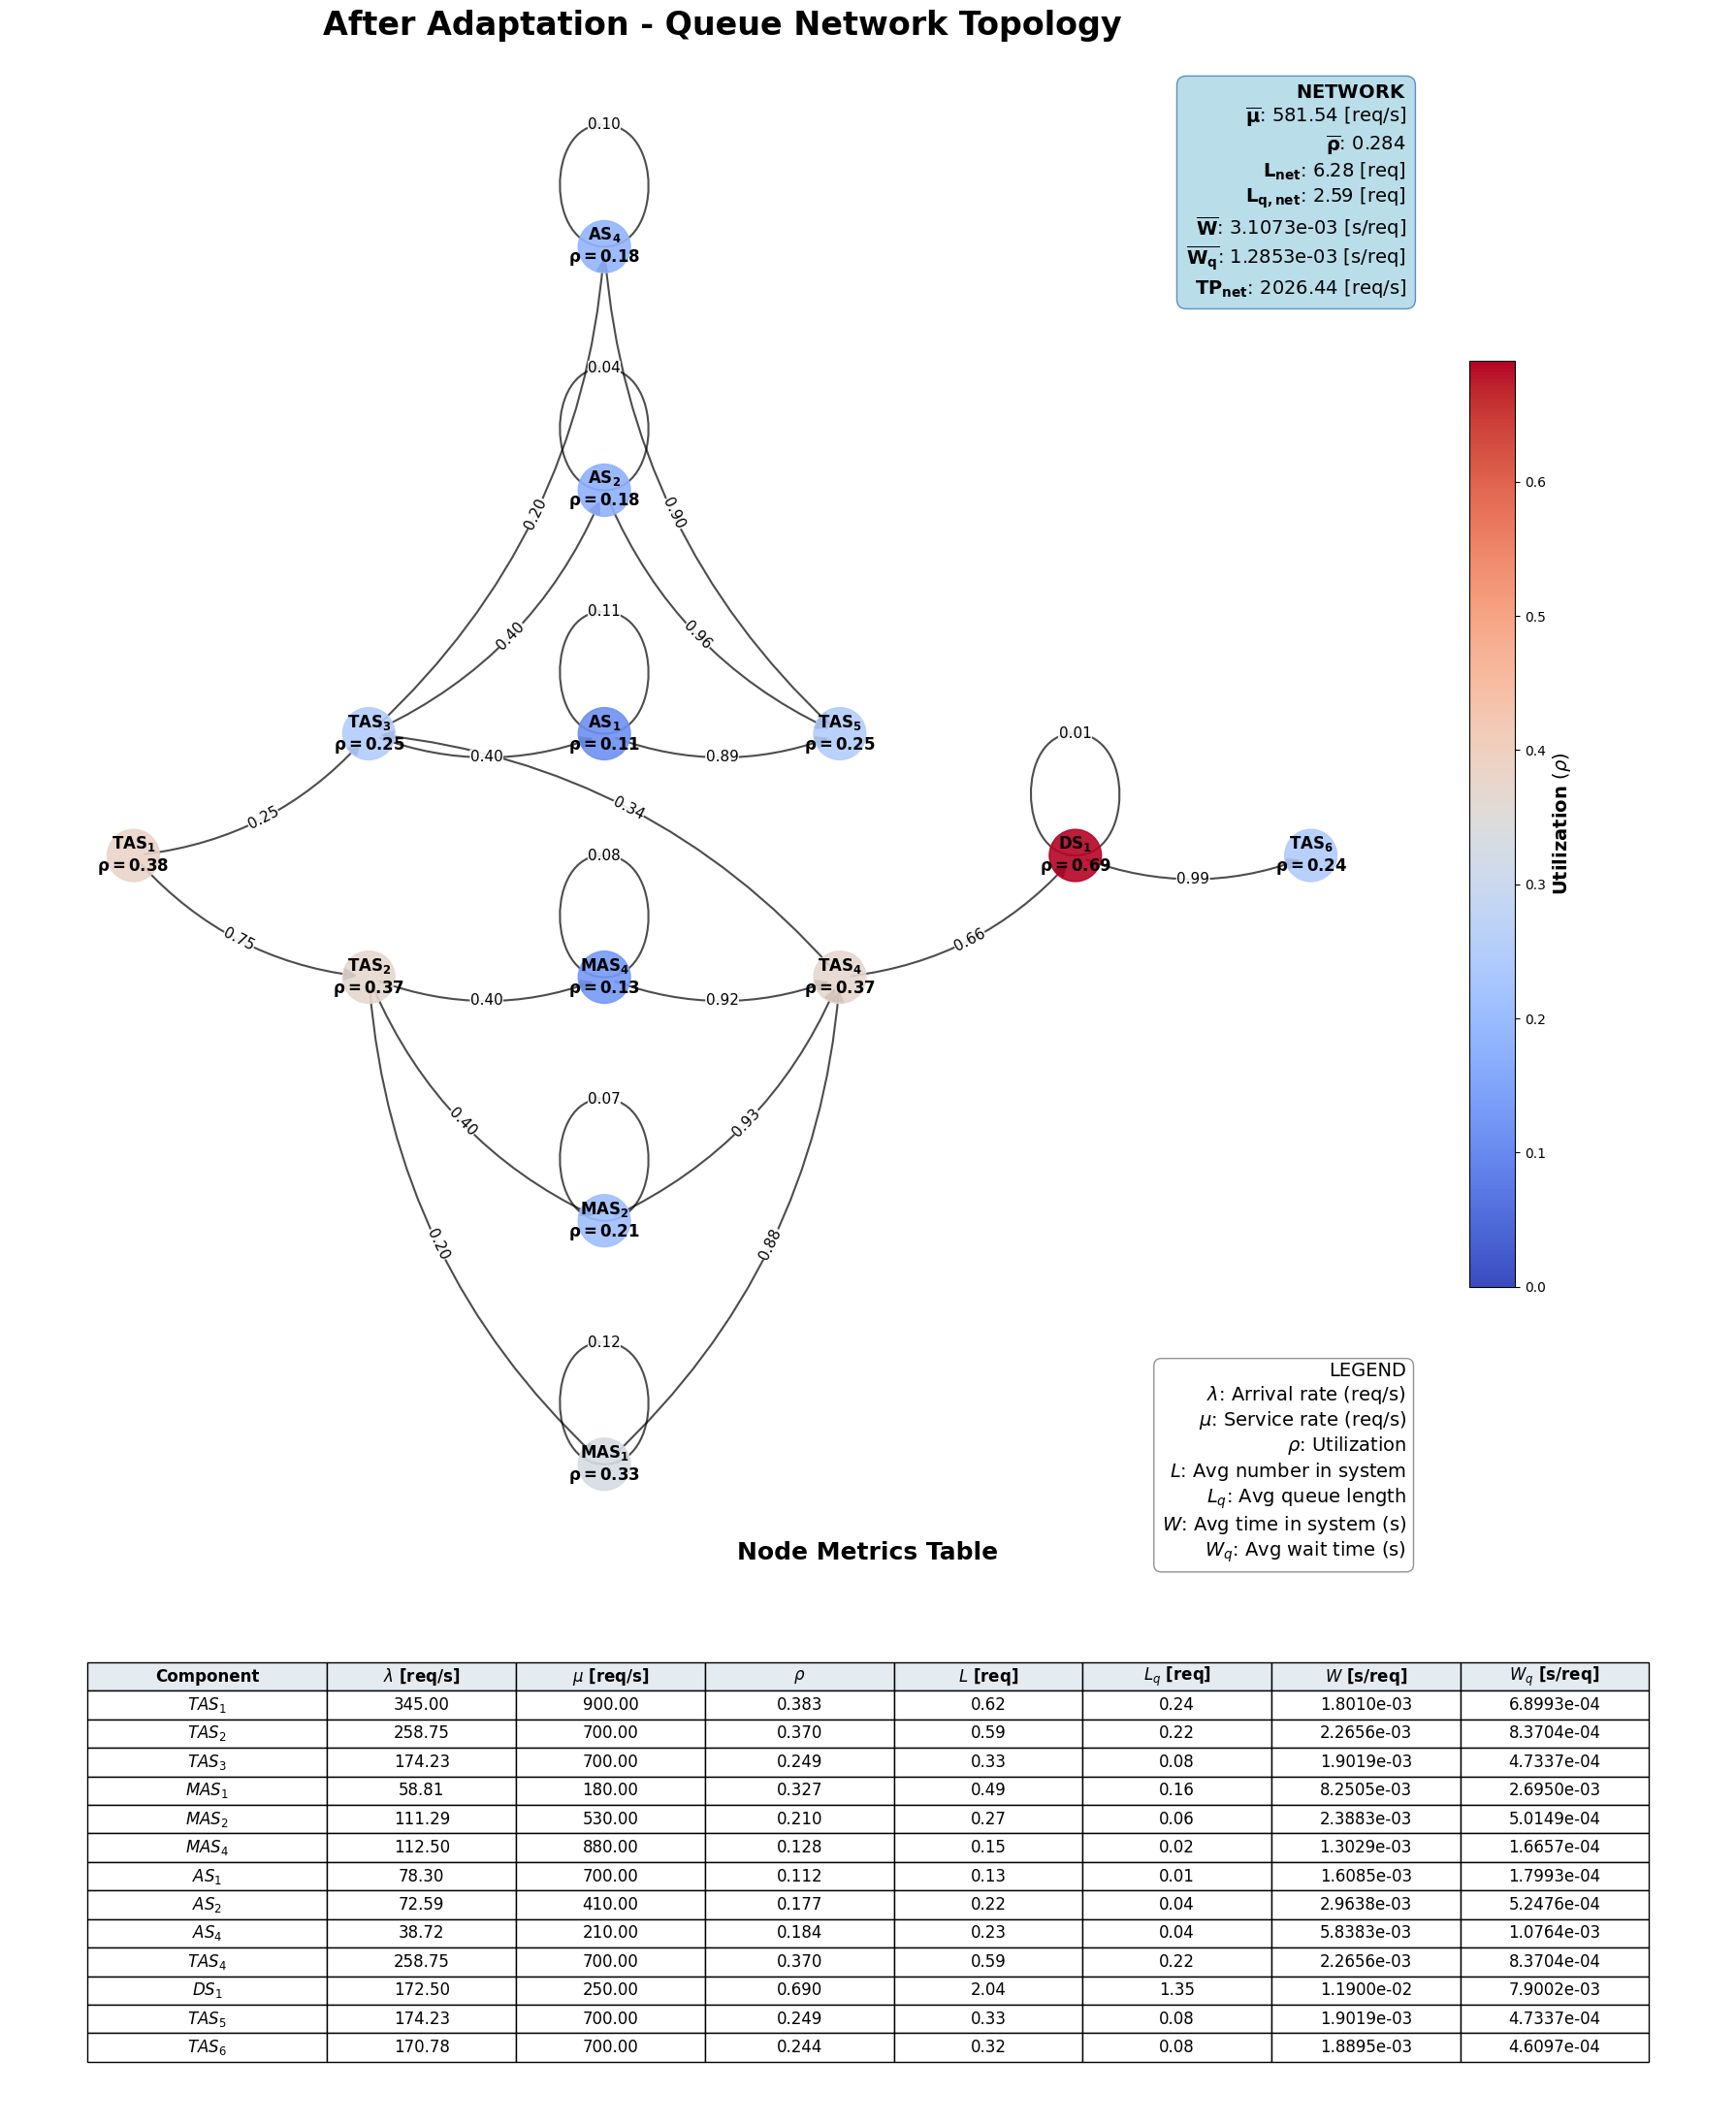

In [5]:
# standalone topology for every adaptation -> data/img/analytic/<adp>/topology.png
for _a in _ADAPTATIONS:
    plot_qn_topology(
        rout=_cfgs[_a].routing,
        nds=_nodes[_a],
        net=_nets[_a],
        title=f"{_DISPLAY[_a]} - Queue Network Topology",
        file_path=str(_IMG_ROOT / _a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one metric. Columns are normalised per-metric across both scenarios so the heat value is directly comparable. Numeric cell labels show the raw value.

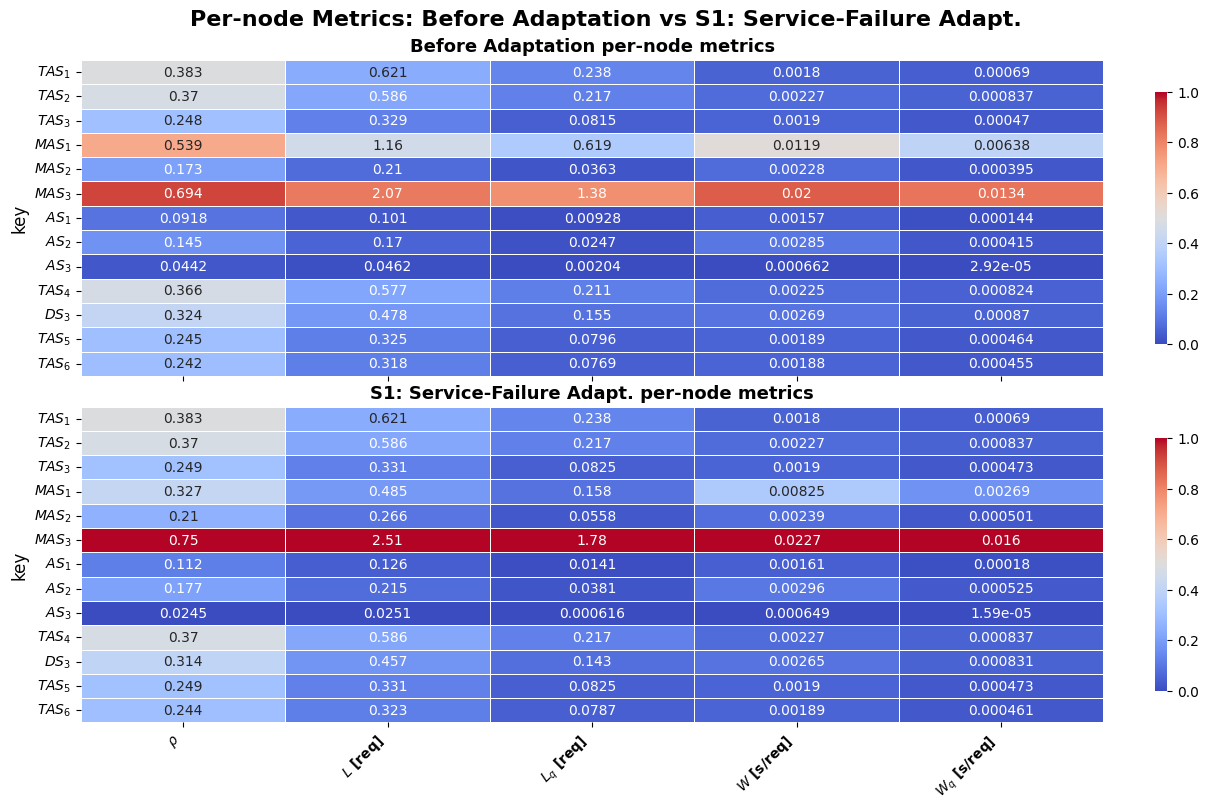

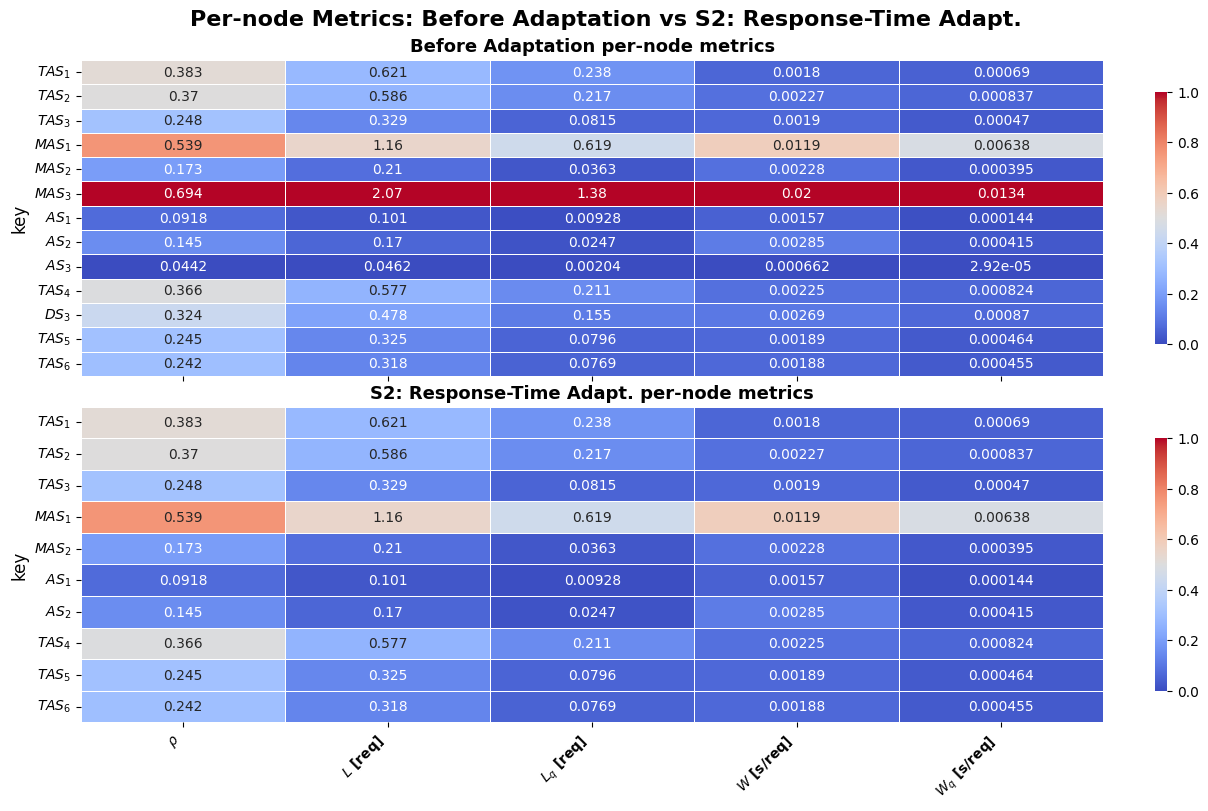

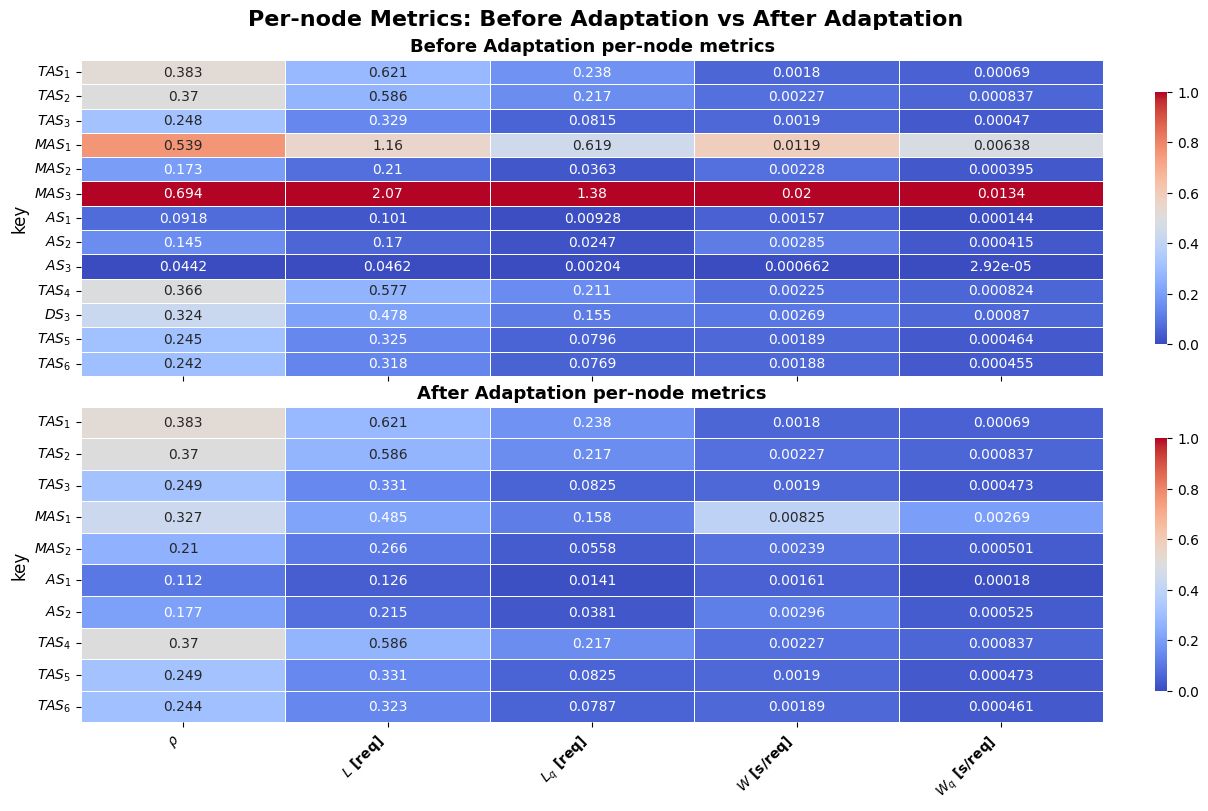

In [6]:
_node_keys = _nodes["baseline"]["key"].tolist()
_heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
_heat_labels = [
    r"$\rho$",
    r"$L$ [req]",
    r"$L_q$ [req]",
    r"$W$ [s/req]",
    r"$W_q$ [s/req]",
]

for _a in ["s1", "s2", "aggregate"]:
    plot_nd_heatmap(
        ndss=[_nodes["baseline"], _nodes[_a]],
        names=[_DISPLAY["baseline"], _DISPLAY[_a]],
        nodes=_node_keys,
        metrics=_heat_metrics,
        labels=_heat_labels,
        title=f"Per-node Metrics: {_DISPLAY['baseline']} vs {_DISPLAY[_a]}",
        file_path=str(_IMG_ROOT / _a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (Δ% vs baseline)

Single-panel view of the per-node, per-metric percent change between baseline and each adaptation. Centred diverging colour scale so positive and negative changes read as equal-intensity colours.

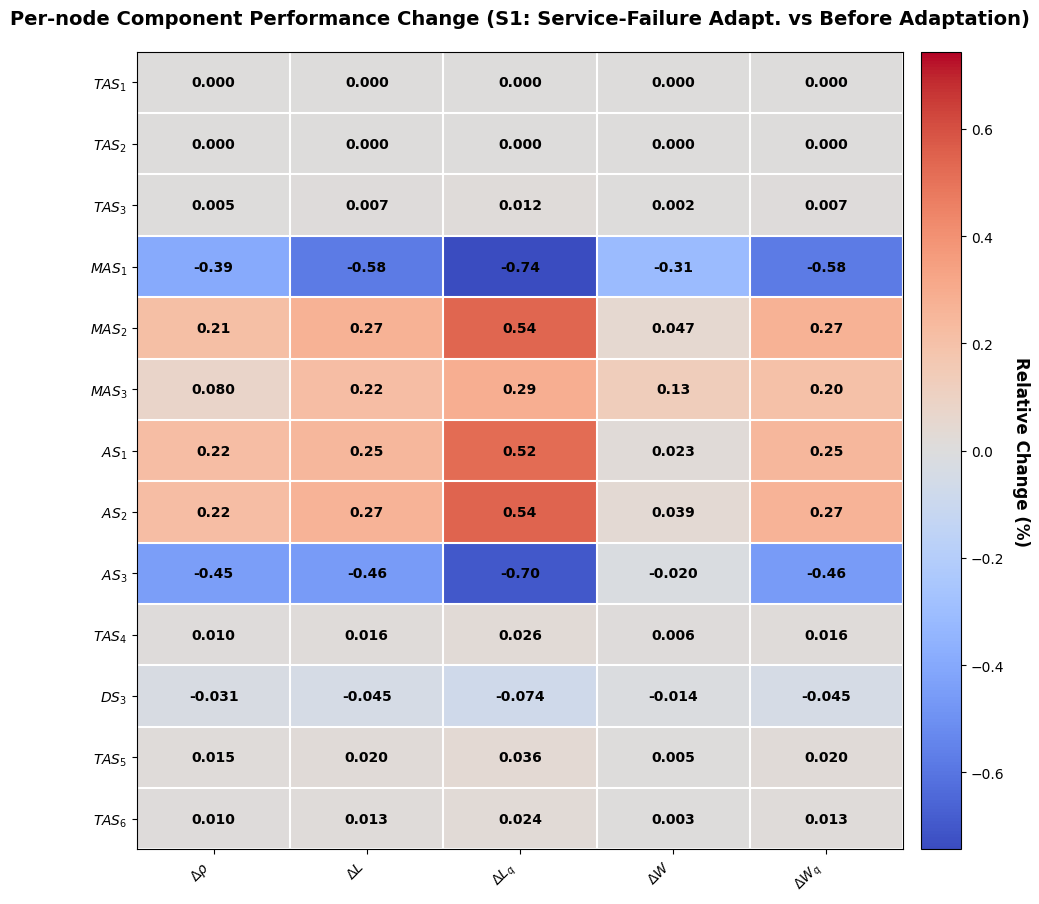

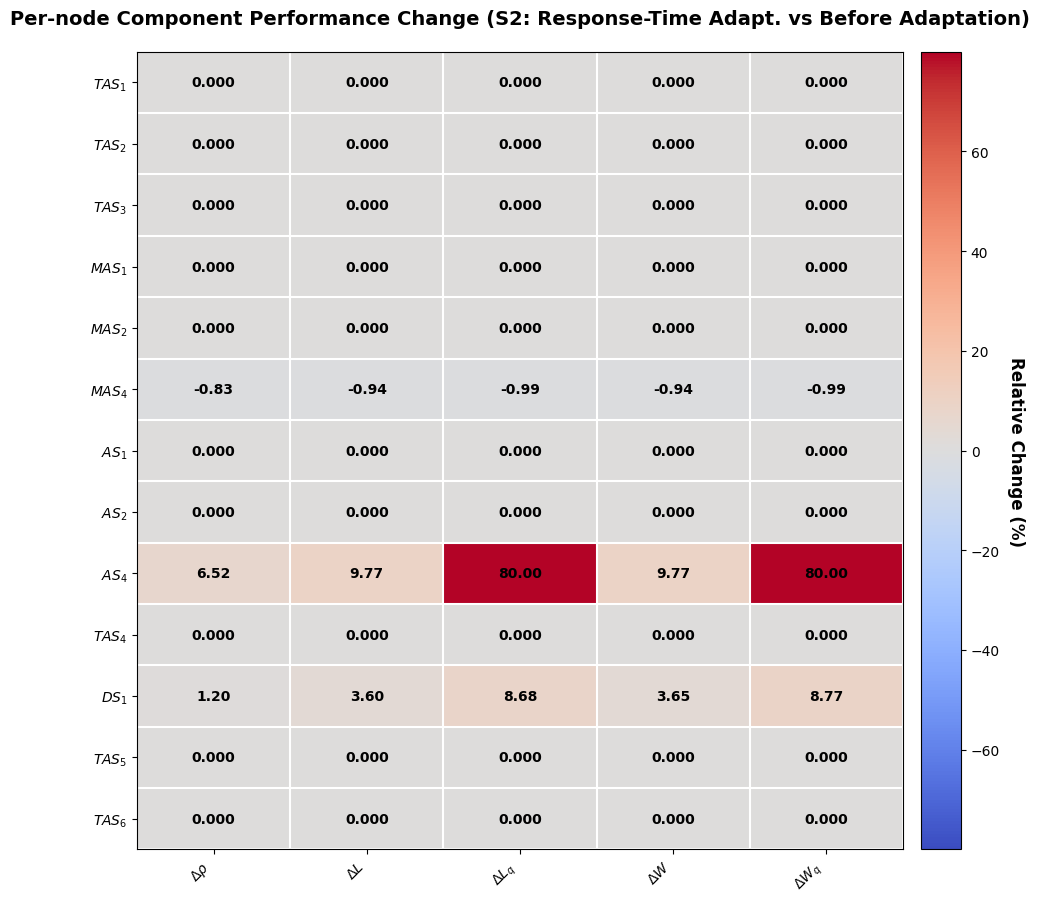

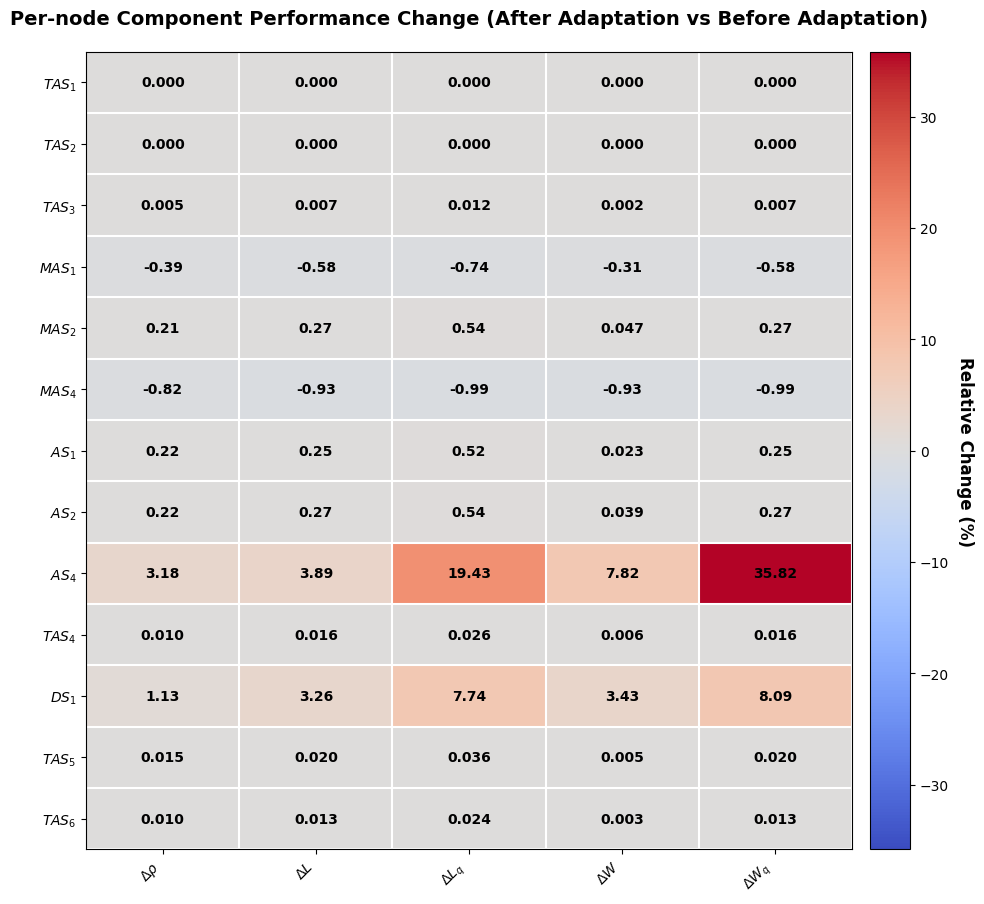

In [7]:
# single-panel delta heatmap per adaptation -> data/img/analytic/<adp>/nd_diffmap_vs_baseline.png
# Match the OLD convention from __OLD__/src/exports/analytical_draft.py:
#     delta = (opti - dflt) / |dflt|        -- RATIO, not percent
# Reference reads "35.82" as 35.82x relative change; do the same here
# so the magnitudes line up with the reference figure.
_diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
_diff_labels = [
    r"$\Delta \rho$",
    r"$\Delta L$",
    r"$\Delta L_q$",
    r"$\Delta W$",
    r"$\Delta W_q$",
]

_bl_nodes = _nodes["baseline"]
for _a in ["s1", "s2", "aggregate"]:
    _ac_nodes = _nodes[_a]
    _rows = []
    # align by positional index (slot) since `key` may differ at swap slots
    for _i in range(len(_ac_nodes)):
        _b_row = _bl_nodes.iloc[_i]
        _c_row = _ac_nodes.iloc[_i]
        _row = {"key": _c_row["key"]}
        for _m in _diff_metrics:
            _b, _c = float(_b_row[_m]), float(_c_row[_m])
            _row[_m] = ((_c - _b) / abs(_b)) if _b else 0.0
        _rows.append(_row)
    _deltas = pd.DataFrame(_rows)

    plot_nd_diffmap(
        deltas=_deltas,
        nodes=_deltas["key"].tolist(),
        metrics=_diff_metrics,
        labels=_diff_labels,
        title=f"Per-node Component Performance Change ({_DISPLAY[_a]} vs {_DISPLAY['baseline']})",
        file_path=str(_IMG_ROOT / _a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the metrics that drive the R1 / R2 / R3 verdicts. Y-axis is log-scaled because the metrics span several orders of magnitude (W in seconds vs L in requests).

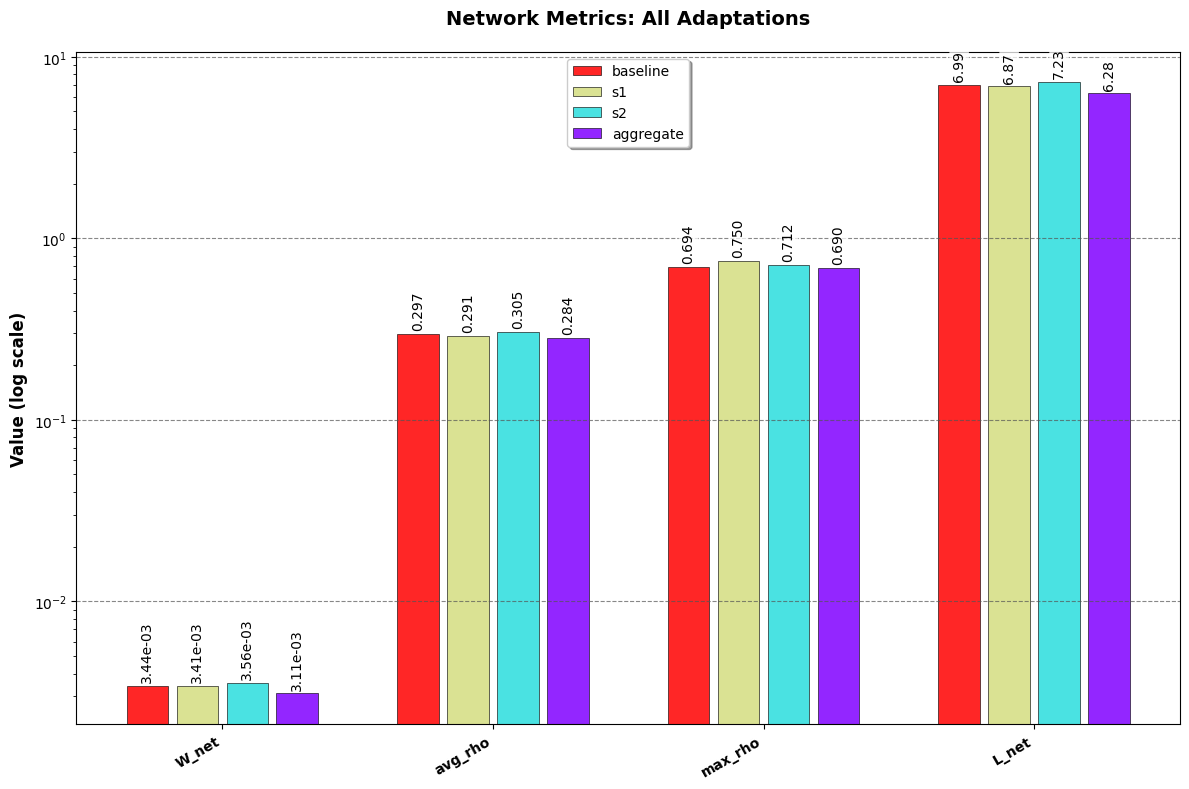

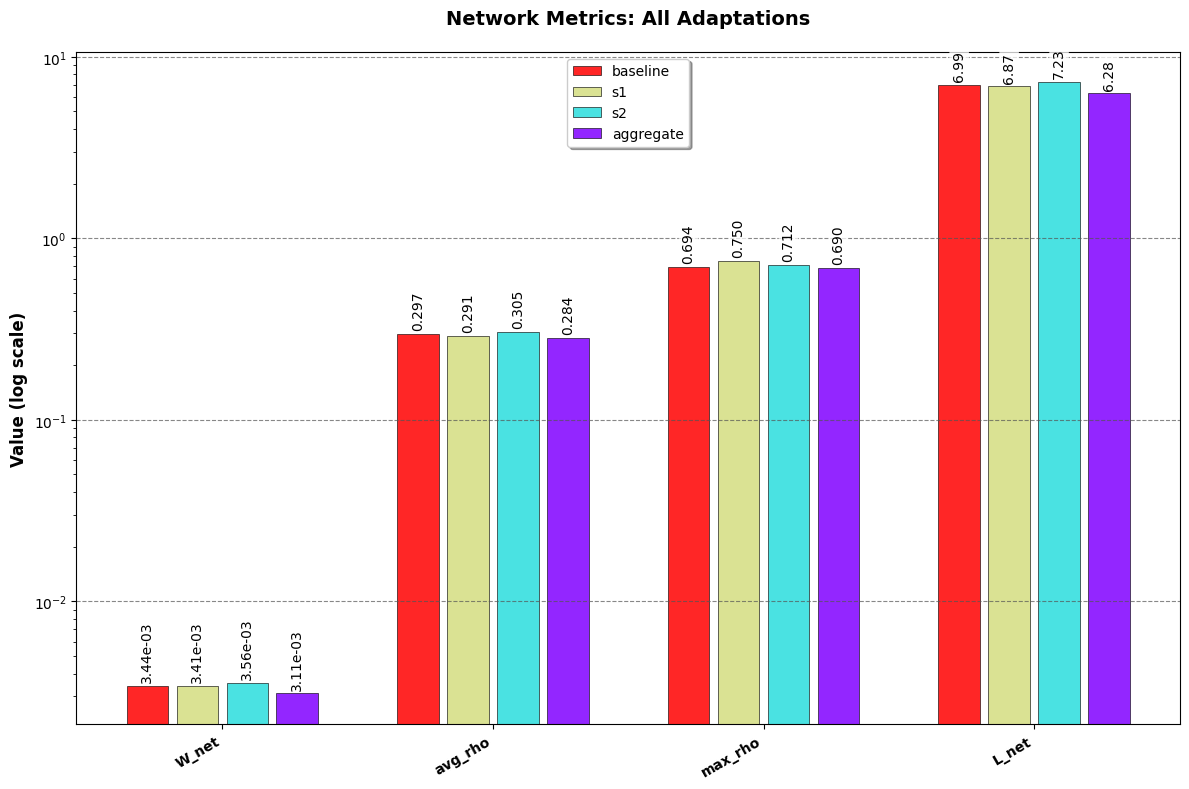

In [8]:
_bar_metrics = ["W_net", "avg_rho", "max_rho", "L_net"]

plot_net_bars(
    nets=[_nets[_a] for _a in _ADAPTATIONS],
    names=_ADAPTATIONS,
    metrics=_bar_metrics,
    title="Network Metrics: All Adaptations",
    file_path=str(_IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 7. Network-wide delta (% change vs baseline)

For every non-baseline adaptation: fractional change on the headline metrics. Green bars = improvement, red = degradation. `total_throughput` flips the sign convention (more is better).

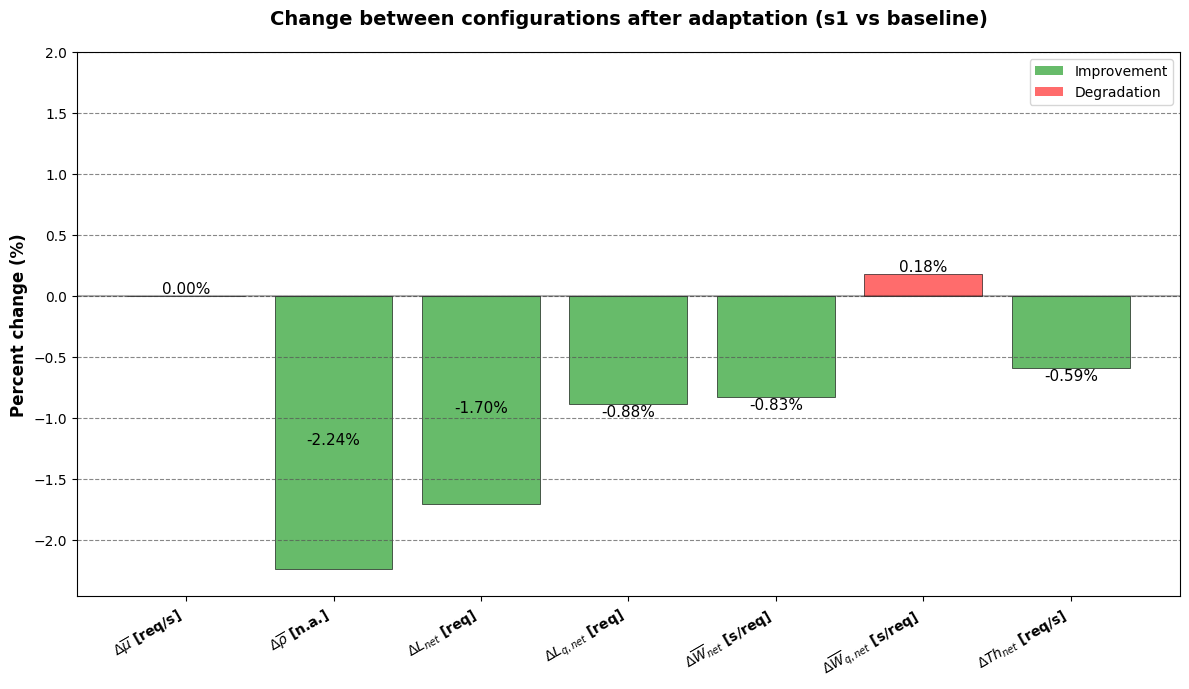

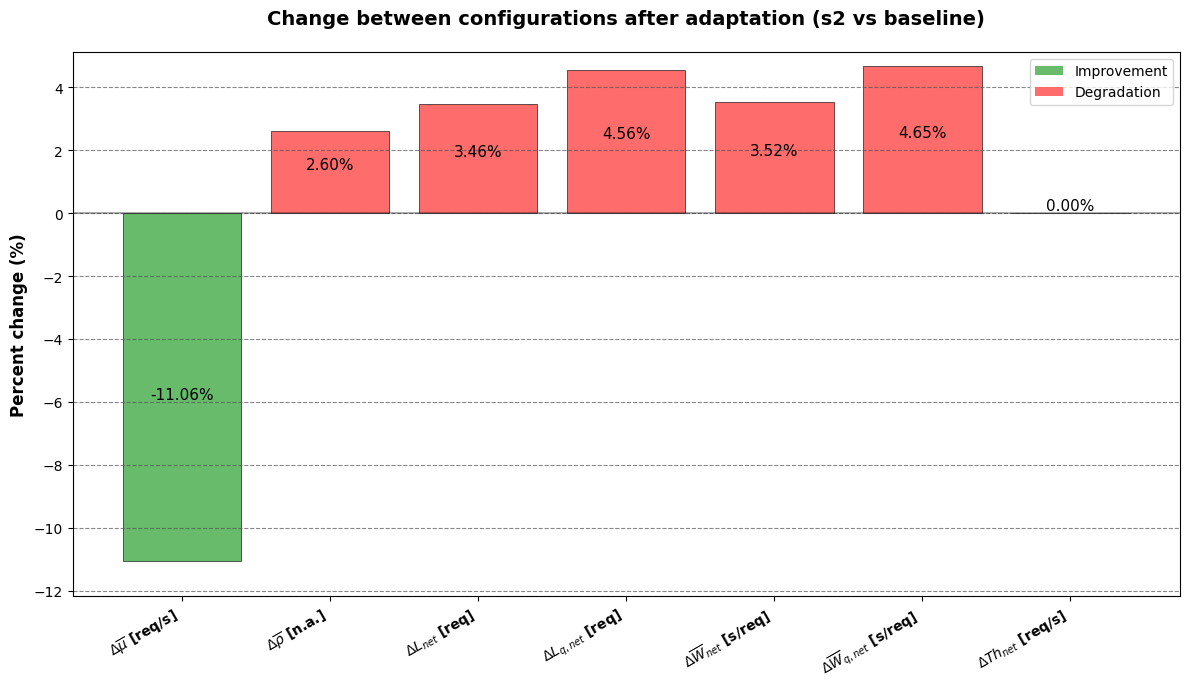

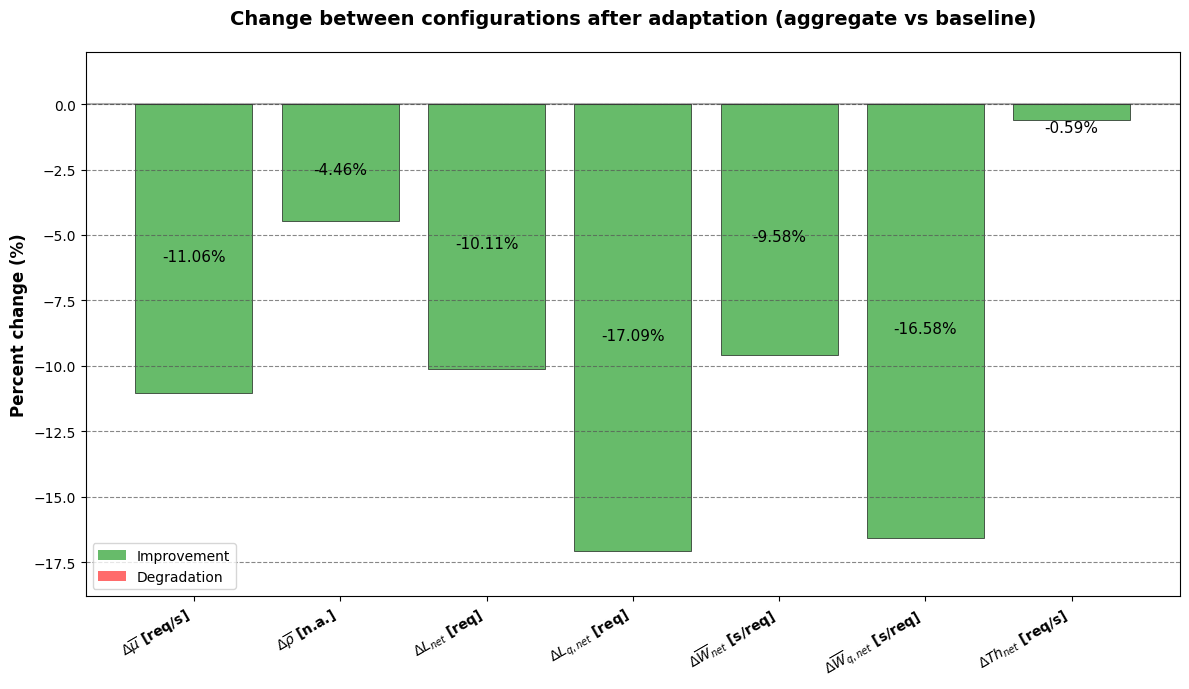

In [9]:
# fractional delta vs baseline for each non-baseline adaptation.
# Metric set + LaTeX labels mirror the reference figure
# __OLD__/data/results/cs1/img/net_analytical_metric_differences.png.
_delta_metrics = [
    "avg_mu", "avg_rho",
    "L_net", "Lq_net",
    "W_net", "Wq_net",
    "total_throughput",
]
_delta_labels = [
    r"$\Delta \overline{\mu}$ [req/s]",
    r"$\Delta \overline{\rho}$ [n.a.]",
    r"$\Delta L_{net}$ [req]",
    r"$\Delta L_{q,net}$ [req]",
    r"$\Delta \overline{W}_{net}$ [s/req]",
    r"$\Delta \overline{W}_{q,net}$ [s/req]",
    r"$\Delta Th_{net}$ [req/s]",
]

_bl = _nets["baseline"].iloc[0]
for _a in ["s1", "s2", "aggregate"]:
    _ac = _nets[_a].iloc[0]
    _row = {
        _m: (_ac[_m] - _bl[_m]) / _bl[_m] if _bl[_m] else 0.0
        for _m in _delta_metrics
    }
    plot_net_delta(
        deltas=pd.DataFrame([_row]),
        metrics=_delta_metrics,
        labels=_delta_labels,
        title=f"Change between configurations after adaptation ({_a} vs baseline)",
        file_path=str(_IMG_ROOT / _a),
        fname="net_delta_vs_baseline.png")

## 8. R1 / R2 / R3 verdict table

Thresholds come from [`data/reference/baseline.json`](data/reference/baseline.json):

- **R1** Availability: `fail_rate <= 0.03 %` (fraction `0.0003`)
- **R2** Performance: `resp_time <= 26 ms`
- **R3** Minimise `cost` subject to `R1 and R2`

`R3` has no numeric threshold; it passes whenever both `R1` and `R2` do.

In [10]:
_req_rows = []
for _a in _ADAPTATIONS:
    _r = _reqs[_a]
    _req_rows.append({
        "adaptation": _a,
        "R1 fail_rate": _r["R1"]["value"],
        "R1 pass": _r["R1"]["pass"],
        "R2 resp_time (s)": _r["R2"]["value"],
        "R2 pass": _r["R2"]["pass"],
        "R3 pass": _r["R3"]["pass"],
    })
pd.DataFrame(_req_rows).set_index("adaptation")

,R1 fail_rate,R1 pass,R2 resp_time (s),R2 pass,R3 pass
adaptation,,,,,
baseline,0.0,True,0.003437,True,True
s1,0.0,True,0.003408,True,True
s2,0.0,True,0.003558,True,True
aggregate,0.0,True,0.003107,True,True


## Summary

At the nominal 345 req/s arrival rate, all four adaptations pass R1, R2, and R3. The aggregate configuration (opti routing + opti services) delivers the lowest `W_net` and the lowest `max_rho`; s1 alone (opti routing, dflt services at the swap slots) is the worst on `max_rho` because opti routing pushes more load into dflt services.

**Next method in the pipeline**: `stochastic.ipynb` (SimPy DES) produces the ground-truth distribution this closed-form solution is compared against.